# Project: **PRCP-1013-WalkRunClass**

**Goal** : To build a binary classification model that predicts whether a person is: Walking OR Running

The Aim of this project is to develop a machine learning model that can automatically recognize human physical activity (Walking or Running) using motion sensor

The dataset contains 88,588 observations with 11 features, including accelerometer and gyroscope readings. These sensors capture motion patterns in three axes (X, Y, Z), which vary depending on whether a person is walking or running


**ML TYPE** :
This Is Supervised Machine Learning Problem(Classification) Beacuse It Has Labeled Data Which Predicts Whether Person Is Walking Or Running

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, classification_report, accuracy_score
from sklearn.svm import SVC
from sklearn.ensemble import  RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
df = pd.read_csv('walkrun.csv')

In [ ]:
df

,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,2017-6-30,13:51:15:847724020,viktor,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,2017-6-30,13:51:16:246945023,viktor,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,2017-6-30,13:51:16:446233987,viktor,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,2017-6-30,13:51:16:646117985,viktor,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,2017-6-30,13:51:16:846738994,viktor,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922
...,...,...,...,...,...,...,...,...,...,...,...
88583,2017-7-9,20:9:15:317911028,viktor,0,0,0.3084,-0.8376,-0.1327,0.4823,2.0124,0.6048
88584,2017-7-9,20:9:15:517889022,viktor,0,0,0.4977,-1.0027,-0.4397,0.1022,-1.2565,-0.0761
88585,2017-7-9,20:9:15:717828989,viktor,0,0,0.4587,-1.1780,-0.2827,-1.4500,-0.2792,-1.2616
88586,2017-7-9,20:9:15:917932987,viktor,0,0,0.2590,-0.8582,-0.0759,-1.5165,0.4560,-1.7755


**Domain Analysis**


1.   **acceleration_x** :

* Measures acceleration(linear movement) along the X-axis.
* Impact on activity: HIGH
* small Acceleration_x --> Walk
* High Acceleration_x -- > Run


2.   **acceleration_y** :
* Measures acceleration(linear movement) along the Y-axis
* Impact on activity: HIGH
* small Acceleration_y --> Walk
* High Acceleration_y -- > Run


3.   **acceleration_z** :
* Measures acceleration(linear movement) along the Z-axis
* Impact on activity: HIGH
* small Acceleration_z --> Walk
* High Acceleration_z -- > Run

4.   **gyro_x** :
* Measures rotation of the wrist around the X-axis.
* Impact on activity: HIGH
* small Gyroscope_x --> Walk
* High Gyroscope_x -- > Run

5.   **gyro_y** :
* Measures rotationof the wrist around the X-axis.
* Impact on activity: HIGH
* small Gyroscope_y --> Walk
* High Gyroscope_y -- > Run

6.   **gyro_z** :
* Measures rotationof the wrist around the X-axis.
* Impact on activity: HIGH
* small Gyroscope_z --> Walk
* High Gyroscope_z -- > Run

7.   **date** :
* date represents the calendar day when the sensor data was recorded.
* Impact on activity: Low(Even We Can Drop It)


8.   **time** :  
* time represents the exact time of day when the sensor reading was recorded.
* Impact on activity: Low(Even We Can Drop It)

9.   **username** :
* username identifies which person generated the data.
* username is only one in entire dataset
* Impact on activity: Low(Even We Can Drop It)

10.  **wrist** :
* wrist indicates which wrist the device was worn on.
* Impact on activity: Medium
* Left Wrist --> 0
* right Wrist --> 1

11. **activity** :
* The target variable is activity, which represents Whether It Is Walk Or Run.
* This is binary classification output varibale
* walk --> 0
* Run --> 1







**Basic Checks**

In [ ]:
df.head()

,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,2017-6-30,13:51:15:847724020,viktor,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,2017-6-30,13:51:16:246945023,viktor,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,2017-6-30,13:51:16:446233987,viktor,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,2017-6-30,13:51:16:646117985,viktor,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,2017-6-30,13:51:16:846738994,viktor,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922


In [ ]:
df.tail()

,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
88583,2017-7-9,20:9:15:317911028,viktor,0,0,0.3084,-0.8376,-0.1327,0.4823,2.0124,0.6048
88584,2017-7-9,20:9:15:517889022,viktor,0,0,0.4977,-1.0027,-0.4397,0.1022,-1.2565,-0.0761
88585,2017-7-9,20:9:15:717828989,viktor,0,0,0.4587,-1.1780,-0.2827,-1.4500,-0.2792,-1.2616
88586,2017-7-9,20:9:15:917932987,viktor,0,0,0.2590,-0.8582,-0.0759,-1.5165,0.4560,-1.7755
88587,2017-7-9,20:9:16:117410004,viktor,0,0,0.3140,-0.8008,-0.0911,0.1183,1.0850,1.2814


In [ ]:
df.count()

,0
date,88588
time,88588
username,88588
wrist,88588
activity,88588
acceleration_x,88588
acceleration_y,88588
acceleration_z,88588
gyro_x,88588
gyro_y,88588


In [ ]:
df.sample(7) ## From here (0 = left wrist, 1 = right wrist),(Class 0 → Walk ,Class 1 → Run)

,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
28419,2017-7-16,14:33:51:648669004,viktor,1,0,-0.4394,-0.9072,-0.1728,-0.0822,0.2724,0.4243
6390,2017-7-10,16:2:40:570034980,viktor,1,0,-0.3086,-1.3079,-0.3991,-0.0033,0.3522,-0.2190
22098,2017-7-15,18:7:16:639716029,viktor,1,1,0.0699,-0.3978,0.2101,-0.0339,-0.5245,-1.3861
77030,2017-7-6,19:5:31:961036026,viktor,0,0,0.2999,-0.7418,-0.0359,-0.5641,-0.8103,-0.7693
86400,2017-7-9,20:0:7:498376011,viktor,0,1,0.9509,-0.8713,-0.9368,0.3064,-1.0216,-1.9256
73682,2017-7-6,18:52:11:674861013,viktor,0,1,1.3058,0.2777,-0.6824,-0.2216,-3.7073,-1.8578
66170,2017-7-6,15:58:35:611262977,viktor,0,0,0.2578,-1.2583,-0.3942,0.0385,0.3700,0.1407


In [ ]:
df.describe()

,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
count,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000
mean,0.522170,0.500801,-0.074811,-0.562585,-0.313956,0.004160,0.037203,0.022327
std,0.499511,0.500002,1.009299,0.658458,0.486815,1.253423,1.198725,1.914423
min,0.000000,0.000000,-5.350500,-3.299000,-3.753800,-4.430600,-7.464700,-9.480000
25%,0.000000,0.000000,-0.381800,-1.033500,-0.376000,-0.920700,-0.644825,-1.345125
50%,1.000000,1.000000,-0.059500,-0.759100,-0.221000,0.018700,0.039300,0.006900
75%,1.000000,1.000000,0.355500,-0.241775,-0.085900,0.888800,0.733700,1.398200
max,1.000000,1.000000,5.603300,2.668000,1.640300,4.874200,8.498000,11.266200


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88588 entries, 0 to 88587
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            88588 non-null  object 
 1   time            88588 non-null  object 
 2   username        88588 non-null  object 
 3   wrist           88588 non-null  int64  
 4   activity        88588 non-null  int64  
 5   acceleration_x  88588 non-null  float64
 6   acceleration_y  88588 non-null  float64
 7   acceleration_z  88588 non-null  float64
 8   gyro_x          88588 non-null  float64
 9   gyro_y          88588 non-null  float64
 10  gyro_z          88588 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 7.4+ MB


In [ ]:
df.shape

(88588, 11)

**Check For NAN Values**

In [ ]:
df.isna().sum()

,0
date,0
time,0
username,0
wrist,0
activity,0
acceleration_x,0
acceleration_y,0
acceleration_z,0
gyro_x,0
gyro_y,0


# Data Preprocessing

**Check For Null Vlaues**

In [ ]:
df.isnull().sum() ## It Does Not Have NaN Values

,0
date,0
time,0
username,0
wrist,0
activity,0
acceleration_x,0
acceleration_y,0
acceleration_z,0
gyro_x,0
gyro_y,0


In [ ]:
df.isna().sum() ## It contains NaN Values in Four Cols

,0
date,0
time,0
username,0
wrist,0
activity,0
acceleration_x,0
acceleration_y,0
acceleration_z,0
gyro_x,0
gyro_y,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isna().sum() #dropped NaN Values

,0
date,0
time,0
username,0
wrist,0
activity,0
acceleration_x,0
acceleration_y,0
acceleration_z,0
gyro_x,0
gyro_y,0


**Check For Duplicate value**

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
## It Does Not Have duplicate Values

**Dropping Cols :**
* Username - It only have one username, It will not affect data
* time & date - time & date is not important and not make any impact on the motion sensors


In [ ]:
df = df.drop(['date', 'time', 'username'], axis=1)

In [ ]:
df  ## after removing unwanted cols

,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922
...,...,...,...,...,...,...,...,...
88583,0,0,0.3084,-0.8376,-0.1327,0.4823,2.0124,0.6048
88584,0,0,0.4977,-1.0027,-0.4397,0.1022,-1.2565,-0.0761
88585,0,0,0.4587,-1.1780,-0.2827,-1.4500,-0.2792,-1.2616
88586,0,0,0.2590,-0.8582,-0.0759,-1.5165,0.4560,-1.7755


**Encoding = Categorical To Numerical**

In [ ]:
## There is no cols with categorical records

# Exploratory Data Analysis

In [ ]:
data_sample = df.sample(100, random_state=41)

In [ ]:
data_sample['activity'].value_counts()

,count
activity,
1,54
0,46


**Univariate Analysis**

<Axes: xlabel='activity', ylabel='Count'>

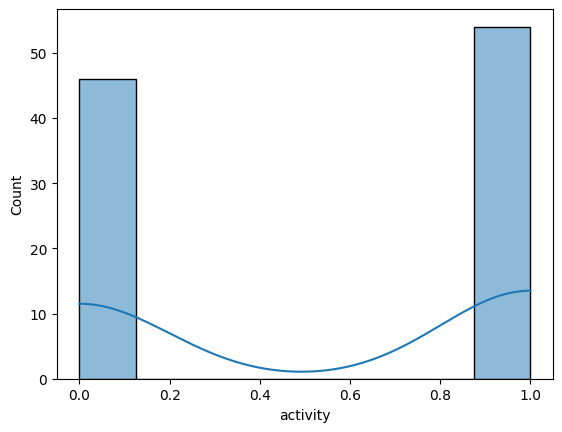

In [ ]:

sns.histplot(x='activity', data=data_sample, kde=True)

<Axes: xlabel='wrist', ylabel='Count'>

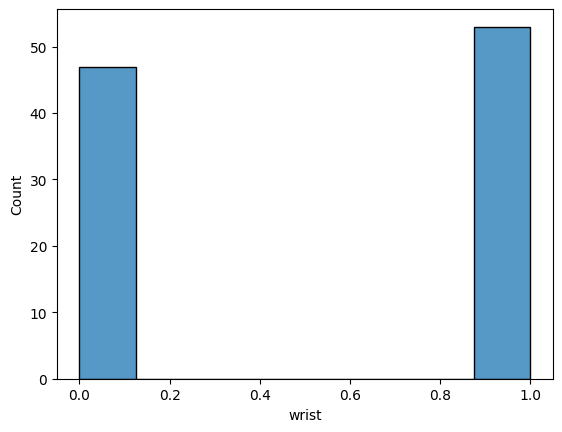

In [ ]:
sns.histplot(x='wrist', data=data_sample)

<Axes: xlabel='acceleration_x', ylabel='Count'>

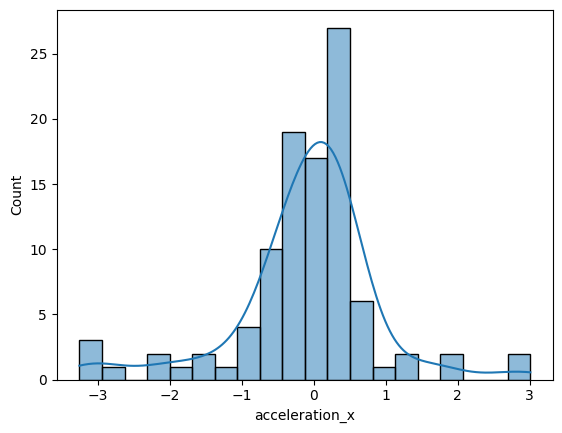

In [ ]:
sns.histplot(x='acceleration_x', data=data_sample, kde=True)

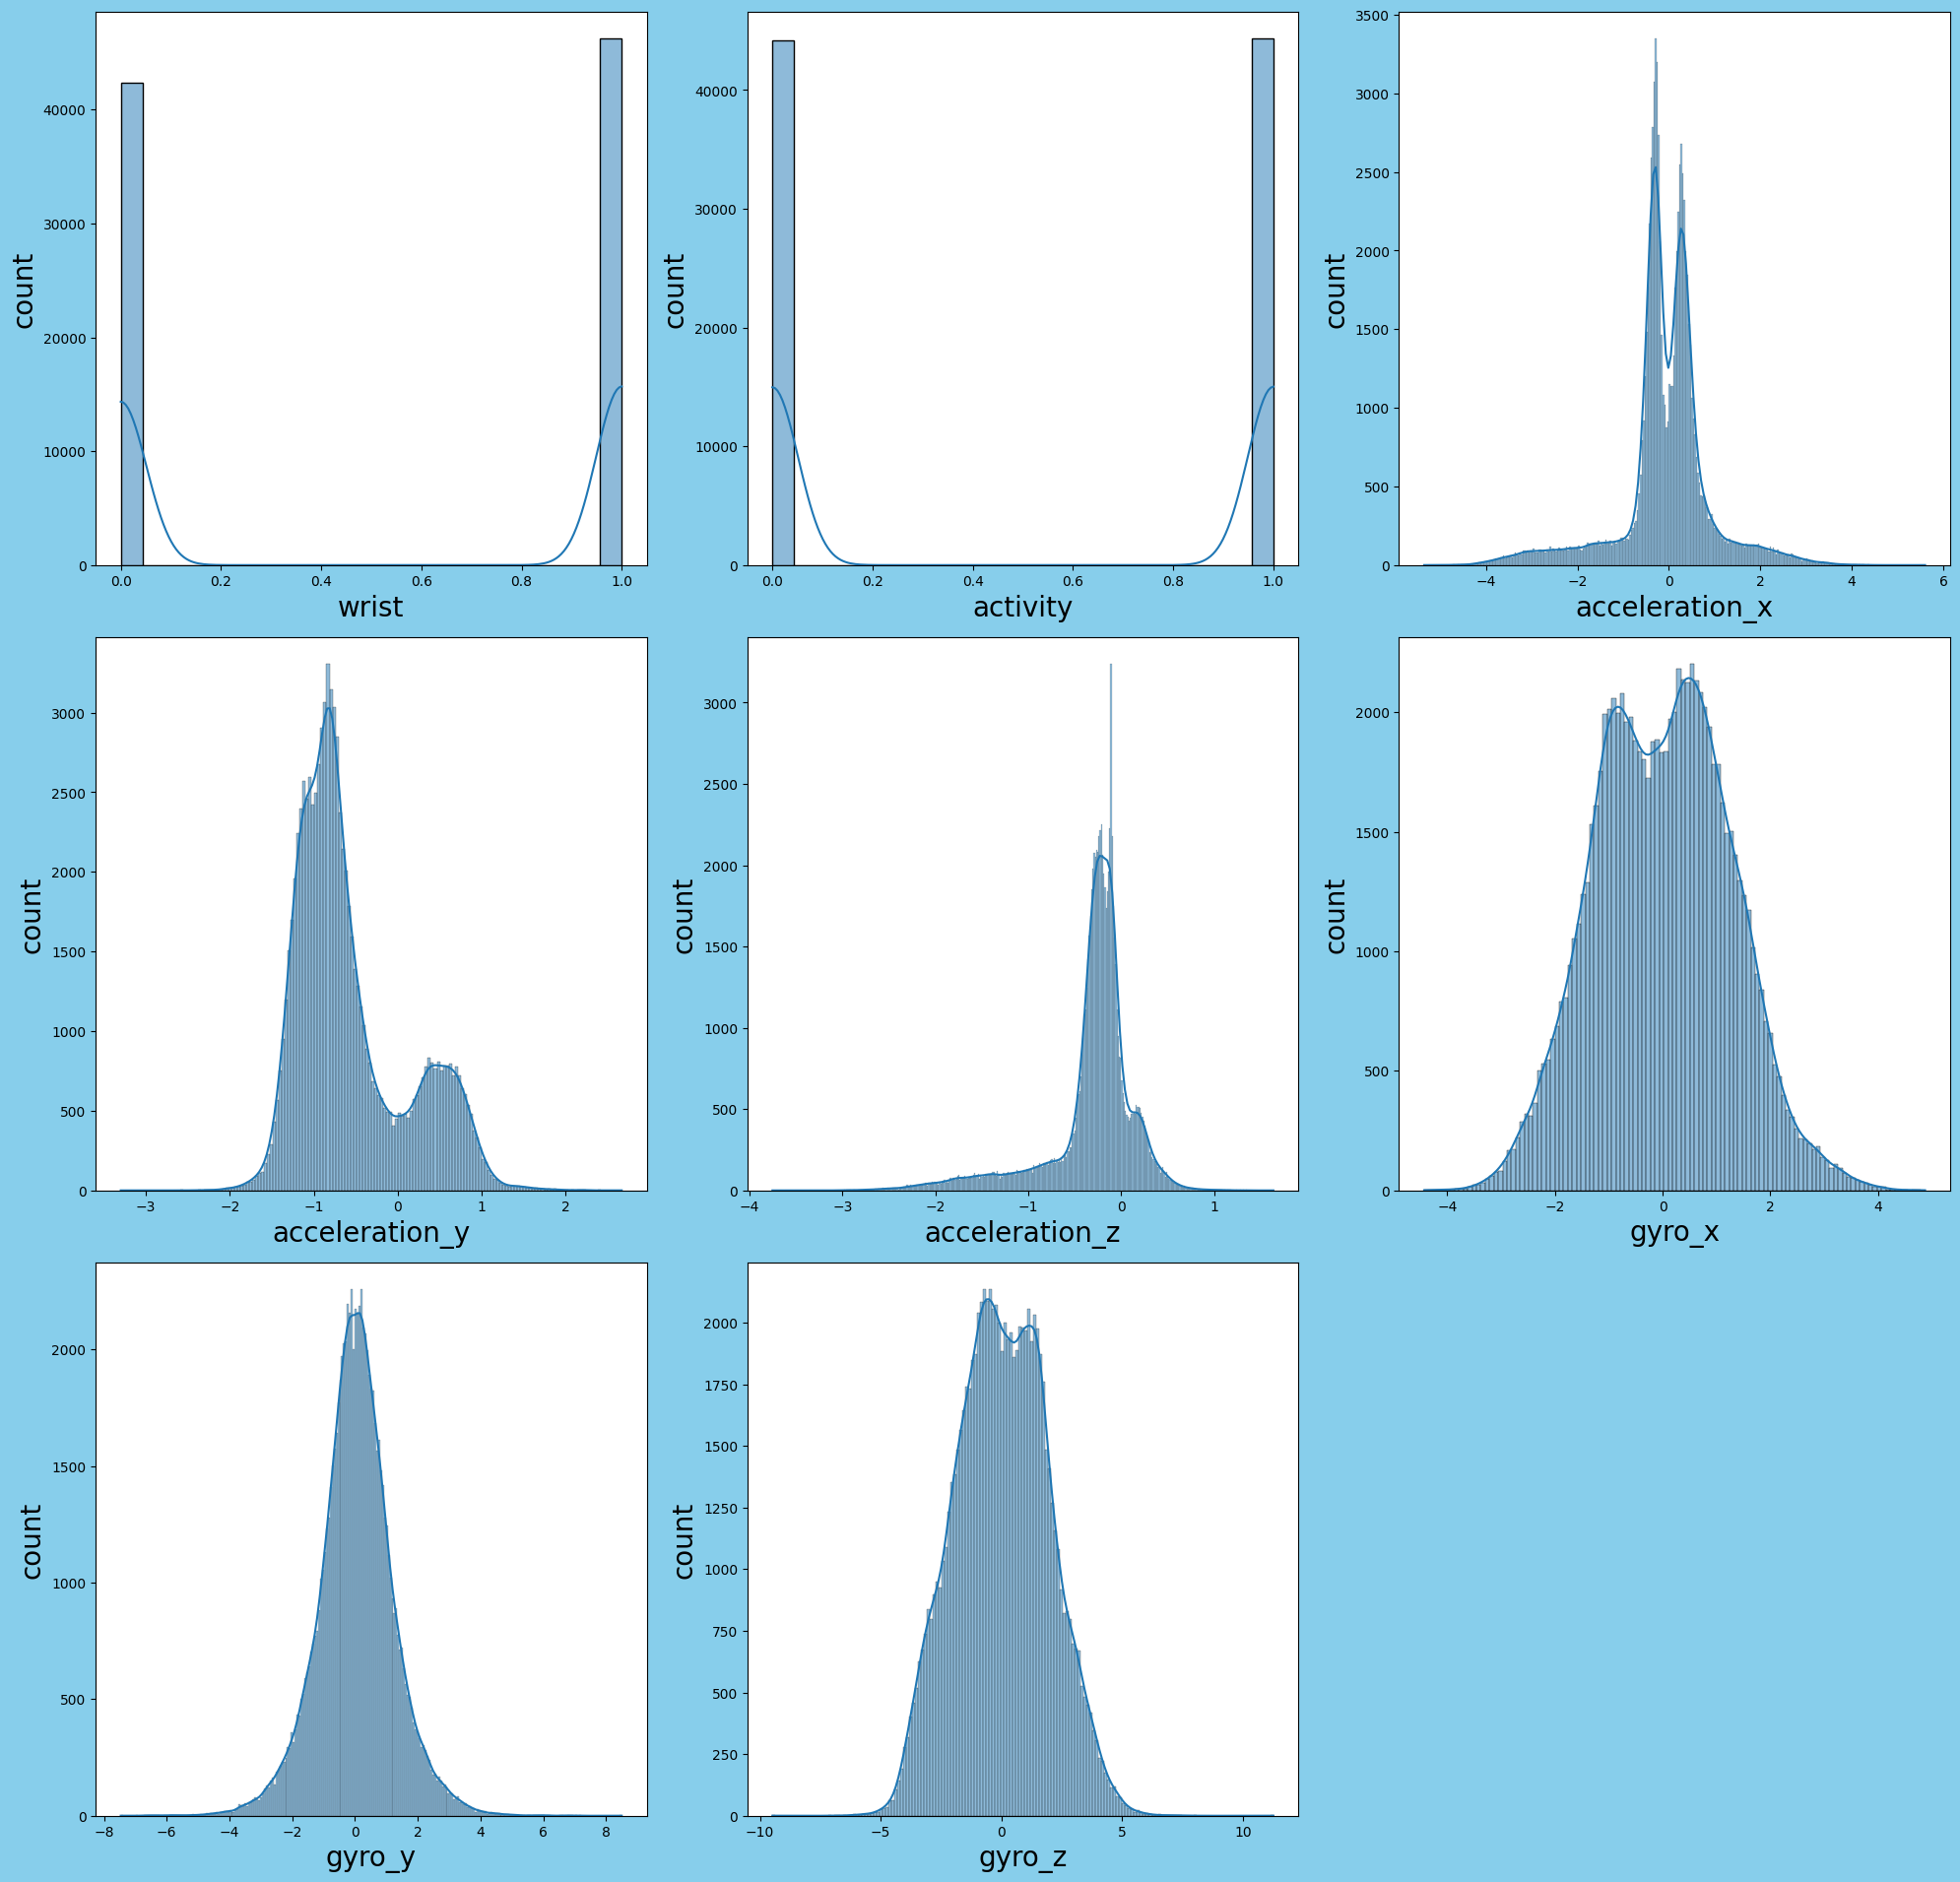

In [ ]:
plt.figure(figsize=(20,25),facecolor='skyblue')
plotnumber=1

for column in df.columns:
    if plotnumber<=8:
        ax=plt.subplot(4,3,plotnumber)
        sns.histplot(df[column],kde=1)
        plt.xlabel(column,fontsize=20)
        plt.ylabel('count',fontsize=20)
    plotnumber+=1
plt.tight_layout()
plt.show()

In [ ]:
df.corr()

,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
wrist,1.000000,-0.113404,-0.609579,0.087091,0.323680,-0.022092,-0.068403,0.008796
activity,-0.113404,1.000000,-0.017747,0.639520,-0.192435,0.040856,0.012055,-0.008106
acceleration_x,-0.609579,-0.017747,1.000000,-0.265169,-0.552374,-0.021705,-0.004091,-0.060849
acceleration_y,0.087091,0.639520,-0.265169,1.000000,0.106220,0.010549,0.072170,-0.022994
acceleration_z,0.323680,-0.192435,-0.552374,0.106220,1.000000,0.035296,-0.021004,0.049621
gyro_x,-0.022092,0.040856,-0.021705,0.010549,0.035296,1.000000,0.094011,0.317769
gyro_y,-0.068403,0.012055,-0.004091,0.072170,-0.021004,0.094011,1.000000,0.287244
gyro_z,0.008796,-0.008106,-0.060849,-0.022994,0.049621,0.317769,0.287244,1.000000


<Axes: >

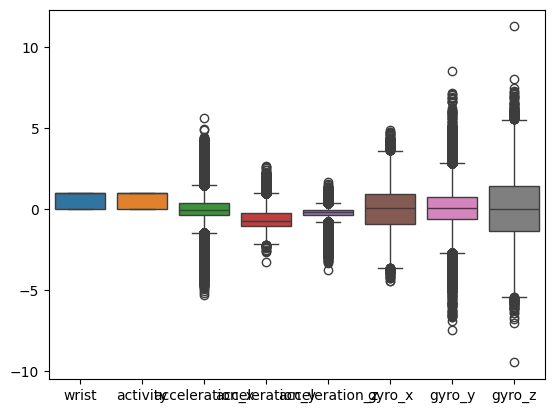

In [ ]:
sns.boxplot(data=df)

**Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler
sScaler = StandardScaler()

In [ ]:
cols = ['acceleration_x','acceleration_y','acceleration_z','gyro_x','gyro_y','gyro_z']

In [ ]:
df[cols] = sScaler.fit_transform(df[cols])

In [ ]:
df[cols].shape

(88588, 6)

**New DataFrame**

In [ ]:
df

,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,0,0,0.336683,-0.332316,0.629311,-0.050391,-0.003924,-1.541949
1,0,0,0.740133,-0.851562,0.163423,-0.143496,-0.013684,0.054624
2,0,0,0.509972,-1.395867,0.793235,-0.729734,0.057642,-1.284481
3,0,0,0.374432,-0.379548,0.827334,0.092339,-0.372984,-1.544039
4,0,0,0.551090,-0.559819,0.718668,0.038726,0.334271,1.290147
...,...,...,...,...,...,...,...,...
88583,0,0,0.379683,-0.417668,0.372333,0.381469,1.647757,0.304257
88584,0,0,0.567240,-0.668406,-0.258300,0.078218,-1.079239,-0.051414
88585,0,0,0.528599,-0.934636,0.064206,-1.160158,-0.263951,-0.670664
88586,0,0,0.330738,-0.448953,0.489011,-1.213213,0.349370,-0.939101


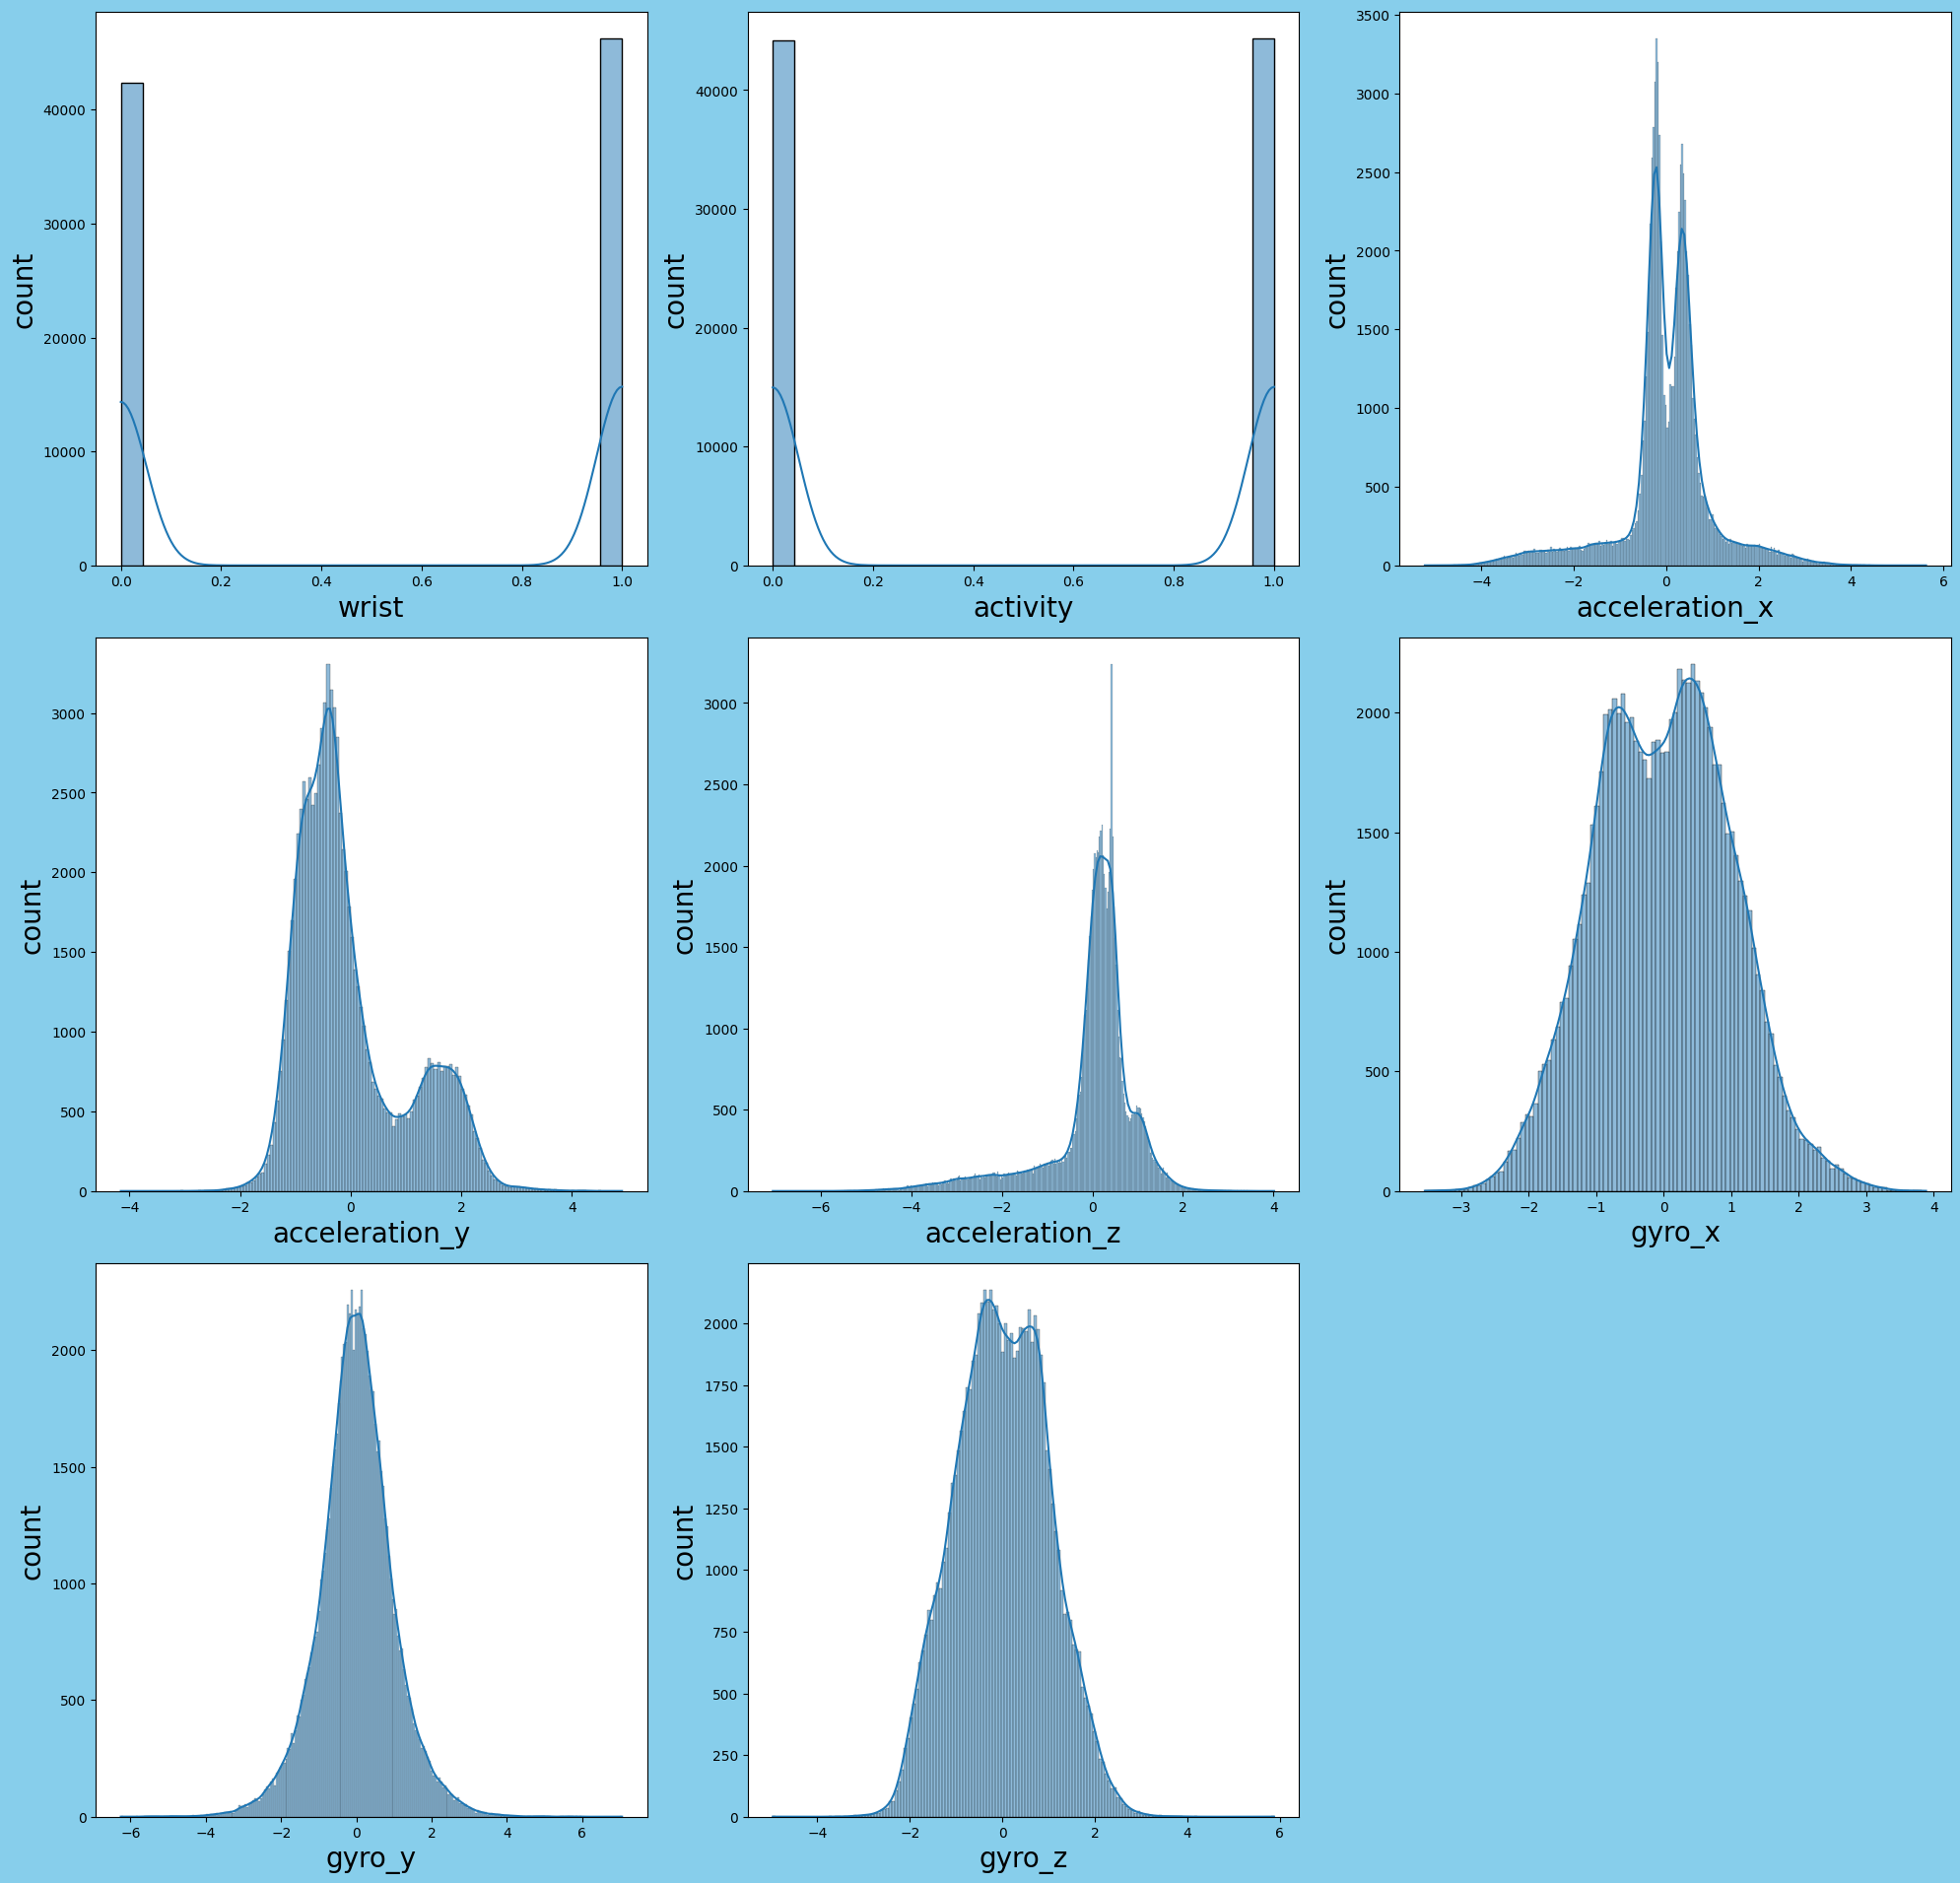

In [ ]:
plt.figure(figsize=(20,25),facecolor='skyblue')
plotnumber=1

for column in df.columns:
    if plotnumber<=8:
        ax=plt.subplot(4,3,plotnumber)
        sns.histplot(df[column],kde=1)
        plt.xlabel(column,fontsize=20)
        plt.ylabel('count',fontsize=20)
    plotnumber+=1
plt.tight_layout()
plt.show()

**Data Split**

In [ ]:
x = df.drop(['activity'], axis=1)
y = df['activity']

In [ ]:
y.shape

(88588,)

In [ ]:
x

,wrist,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,0,0.336683,-0.332316,0.629311,-0.050391,-0.003924,-1.541949
1,0,0.740133,-0.851562,0.163423,-0.143496,-0.013684,0.054624
2,0,0.509972,-1.395867,0.793235,-0.729734,0.057642,-1.284481
3,0,0.374432,-0.379548,0.827334,0.092339,-0.372984,-1.544039
4,0,0.551090,-0.559819,0.718668,0.038726,0.334271,1.290147
...,...,...,...,...,...,...,...
88583,0,0.379683,-0.417668,0.372333,0.381469,1.647757,0.304257
88584,0,0.567240,-0.668406,-0.258300,0.078218,-1.079239,-0.051414
88585,0,0.528599,-0.934636,0.064206,-1.160158,-0.263951,-0.670664
88586,0,0.330738,-0.448953,0.489011,-1.213213,0.349370,-0.939101


In [ ]:
y

,activity
0,0
1,0
2,0
3,0
4,0
...,...
88583,0
88584,0
88585,0
88586,0


**Train Test Split**

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=45)

In [ ]:
x_train.shape, y_train.shape

((70870, 7), (70870,))

In [ ]:
x_test.shape, y_test.shape

((17718, 7), (17718,))



> **Model Implementation**



## Models used: Used mutliple classification model
#### 1.Logistic Regression
#### 2.Random Forest
#### 3.XGBoost
#### 4.SVM
#### 5.KNN
#### 6.Decision Tree Classifier

 ## **Logistic Regression**

In [ ]:
lR = LogisticRegression()
lR.fit(x_train, y_train)  ##training

LogisticRegression()

In [ ]:
y_pred_probabilty = lR.predict_proba(x_test)    ##probabilty of each class [[ Prob of walk(0), prob of run(1) ]]

In [ ]:
y_pred_probabilty

array([[7.32357073e-01, 2.67642927e-01],
       [7.48347671e-01, 2.51652329e-01],
       [7.90858473e-01, 2.09141527e-01],
       ...,
       [7.18931469e-01, 2.81068531e-01],
       [1.69632451e-04, 9.99830368e-01],
       [7.64094466e-03, 9.92359055e-01]])

In [ ]:
y_pred_lr = lR.predict(x_test)

In [ ]:
y_pred_lr

array([0, 0, 0, ..., 0, 1, 1])

**Model Evulation of Logistic Regression**

In [ ]:
print('recall Of LR :',recall_score(y_test, y_pred_lr, average='weighted'))
print('precision Of LR :',precision_score(y_test, y_pred_lr, average='weighted'))
print('F1 Of LR :',f1_score(y_test, y_pred_lr, average='weighted'))
print('Accuracy Score Of LR :', accuracy_score(y_test, y_pred_lr))
print('Model Score For LR Training ', lR.score(x_train, y_train))
print('Model score for LR testing', lR.score(x_test, y_test))
print('Confusion Matrix Of LR :',confusion_matrix(y_test, y_pred_lr))



recall Of LR : 0.8552319674906874
precision Of LR : 0.858763767254238
F1 Of LR : 0.8548235911658987
Accuracy Score Of LR : 0.8552319674906874
Model Score For LR Training  0.8622971638210809
Model score for LR testing 0.8552319674906874
Confusion Matrix Of LR : [[8073  838]
 [1727 7080]]


In [ ]:
cl_report_lr = classification_report(y_test, y_pred_lr)
print(cl_report_lr)

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      8911
           1       0.89      0.80      0.85      8807

    accuracy                           0.86     17718
   macro avg       0.86      0.85      0.85     17718
weighted avg       0.86      0.86      0.85     17718



## **Random Forest**

In [ ]:
rfc = RandomForestClassifier()
rfc.fit(x_train, y_train) ## training

RandomForestClassifier()

In [ ]:
y_probability = rfc.predict_proba(x_test)
y_probability

array([[1.  , 0.  ],
       [0.24, 0.76],
       [0.85, 0.15],
       ...,
       [0.  , 1.  ],
       [0.  , 1.  ],
       [0.  , 1.  ]])

In [ ]:
y_pred_rfc = rfc.predict(x_test)
y_pred_rfc

array([0, 1, 0, ..., 1, 1, 1])

**Model Evulation of Random Forest Classifier**

In [ ]:
print('Recall score Of rfc :', recall_score(y_test, y_pred_rfc))
print('Precision score Of rfc :', precision_score(y_test, y_pred_rfc))
print('F1 Score Of rfc :',f1_score(y_test, y_pred_rfc))
print('Accuracy Score Of rfc :', accuracy_score(y_test, y_pred_rfc))
print('Model Score For rfc Training ', rfc.score(x_train, y_train))
print('Model score for rfc testing', rfc.score(x_test, y_test))
print('Confusion Matrix Of rfc :',confusion_matrix(y_test, y_pred_rfc))


Recall score Of rfc : 0.992960145338935
Precision score Of rfc : 0.9931856899488927
F1 Score Of rfc : 0.9930729048376107
Accuracy Score Of rfc : 0.9931143469917598
Model Score For rfc Training  1.0
Model score for rfc testing 0.9931143469917598
Confusion Matrix Of rfc : [[8851   60]
 [  62 8745]]


In [ ]:
cl_report_rfc = classification_report(y_test, y_pred_rfc)
print(cl_report_rfc)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      8911
           1       0.99      0.99      0.99      8807

    accuracy                           0.99     17718
   macro avg       0.99      0.99      0.99     17718
weighted avg       0.99      0.99      0.99     17718



## **Supprt Vector Classifier**

In [ ]:
svc = SVC()
svc.fit(x_train, y_train)  #training

SVC()

In [ ]:
y_pred_svc = svc.predict(x_test)
y_pred_svc

array([0, 1, 0, ..., 1, 1, 1])

**Model Evulation of Suport Vector Classifier**

In [ ]:
print('Precision Of svc :',precision_score(y_test, y_pred_svc))
print('recall score Of svc :',recall_score(y_test, y_pred_svc))
print('f1 score Of svc :',f1_score(y_test, y_pred_svc))
print('Accuracy Score Of svc :', accuracy_score(y_test, y_pred_svc))
print('Model Score For svc Training ', svc.score(x_train, y_train))
print('Model score for svc testing', svc.score(x_test, y_test))
print('Confusion Matrix Of svc :',confusion_matrix(y_test, y_pred_svc))



Precision Of svc : 0.994289629968022
recall score Of svc : 0.9885318496650392
f1 score Of svc : 0.9914023800034163
Accuracy Score Of svc : 0.9914775934078338
Model Score For svc Training  0.9910681529561168
Model score for svc testing 0.9914775934078338
Confusion Matrix Of svc : [[8861   50]
 [ 101 8706]]


In [ ]:
cl_report_svc = classification_report(y_test, y_pred_svc)
print(cl_report_svc)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      8911
           1       0.99      0.99      0.99      8807

    accuracy                           0.99     17718
   macro avg       0.99      0.99      0.99     17718
weighted avg       0.99      0.99      0.99     17718



## **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred_dt = dt.predict(x_test)
y_pred_dt

array([0, 1, 0, ..., 1, 1, 1])

**Model Evulation of Decision Tree Classifier**

In [ ]:
print('Precision Of dt :',precision_score(y_test, y_pred_dt))
print('recall score Of dt :',recall_score(y_test, y_pred_dt))
print('f1 score Of dt :',f1_score(y_test, y_pred_dt))
print('Accuracy Score Of dt :', accuracy_score(y_test, y_pred_dt))
print('Model Score For dt Training ', dt.score(x_train, y_train))
print('Model score for dt testing', dt.score(x_test, y_test))
print('Confusion Matrix Of dt :',confusion_matrix(y_test, y_pred_dt))



Precision Of dt : 0.9869139736003641
recall score Of dt : 0.9847848302486658
f1 score Of dt : 0.985848252344416
Accuracy Score Of dt : 0.9859464950897392
Model Score For dt Training  1.0
Model score for dt testing 0.9859464950897392
Confusion Matrix Of dt : [[8796  115]
 [ 134 8673]]


In [ ]:
cl_report_dt = classification_report(y_test, y_pred_dt)
print(cl_report_dt)

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      8911
           1       0.99      0.98      0.99      8807

    accuracy                           0.99     17718
   macro avg       0.99      0.99      0.99     17718
weighted avg       0.99      0.99      0.99     17718



## **K Nearest Neighbors - Classifier**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred_knn = knn.predict(x_test)
y_pred_knn

array([0, 1, 0, ..., 1, 1, 1])

**Model Evulation of K Nearest Neighbors Classifier**

In [ ]:
print('Precision Of knn :',precision_score(y_test, y_pred_knn))
print('recall score Of knn :',recall_score(y_test, y_pred_knn))
print('f1 score Of knn :',f1_score(y_test, y_pred_knn))
print('Accuracy Score Of knn :', accuracy_score(y_test, y_pred_knn))
print('Model Score For knn Training ', knn.score(x_train, y_train))
print('Model score for knn testing', knn.score(x_test, y_test))
print('Confusion Matrix Of knn :',confusion_matrix(y_test, y_pred_knn))



Precision Of knn : 0.9953121426938029
recall score Of knn : 0.9884183036221188
f1 score Of knn : 0.9918532444596365
Accuracy Score Of knn : 0.9919291116378823
Model Score For knn Training  0.993579793988994
Model score for knn testing 0.9919291116378823
Confusion Matrix Of knn : [[8870   41]
 [ 102 8705]]


## **XG BOOST**

In [ ]:
!pip install xgboost
from xgboost import XGBClassifier


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 1.2 MB/s eta 0:00:00


In [ ]:
xgb = XGBClassifier()
xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb.predict(x_test)
y_pred_xgb

array([0, 1, 0, ..., 1, 1, 1])

**Model Evulation of XG Boost Classifier**

In [ ]:
print('Precision Of xgb :',precision_score(y_test, y_pred_xgb))
print('recall score Of xgb :',recall_score(y_test, y_pred_xgb))
print('f1 score Of xgb :',f1_score(y_test, y_pred_xgb))
print('Accuracy Score Of xgb :', accuracy_score(y_test, y_pred_xgb))
print('Model Score For xgb Training ', xgb.score(x_train, y_train))
print('Model score for xgb testing', xgb.score(x_test, y_test))
print('Confusion Matrix Of xgb :',confusion_matrix(y_test, y_pred_xgb))



Precision Of xgb : 0.9945386278302424
recall score Of xgb : 0.9925059611672533
f1 score Of xgb : 0.9935212548306434
Accuracy Score Of xgb : 0.9935658652218083
Model Score For Training 0.9987582898264428
Model score for testing 0.9935658652218083
Confusion Matrix Of xgb : [[8863   48]
 [  66 8741]]


**Model Report**

In [ ]:
models = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Support Vector Classifier" , "XGB"],
    "Accuracy Score": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rfc),
        accuracy_score(y_test, y_pred_svc),
        accuracy_score(y_test, y_pred_xgb)
        ],
    "precision Score" : [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rfc),
        precision_score(y_test, y_pred_svc),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall Score " : [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rfc),
        recall_score(y_test, y_pred_svc),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 - Score " : [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rfc),
        f1_score(y_test, y_pred_svc),
        f1_score(y_test, y_pred_xgb)
    ],
     "Training Model Score" : [
        lR.score(x_train,y_train),
        dt.score(x_train,y_train),
        rfc.score(x_train,y_train),
        svc.score(x_train,y_train),
        xgb.score(x_train,y_train)
    ],
    "Testing Model Score" : [
        lR.score(x_test,y_test),
        dt.score(x_test,y_test),
        rfc.score(x_test,y_test),
        svc.score(x_test,y_test),
        xgb.score(x_test,y_test)
    ]

})
models

,Model,Accuracy Score,precision Score,Recall Score,F1 - Score,Training Model Score,Testing Model Score
0,Logistic Regression,0.855232,0.894165,0.803906,0.846637,0.862297,0.855232
1,Decision Tree,0.985946,0.986914,0.984785,0.985848,1.000000,0.985946
2,Random Forest,0.993453,0.993190,0.993641,0.993416,1.000000,0.993453
3,Support Vector Classifier,0.991478,0.994290,0.988532,0.991402,0.991068,0.991478
4,XGB,0.993566,0.994539,0.992506,0.993521,0.998758,0.993566


In [ ]:
## slightly model is overfitting in case of (DT), we can further evaluate with GridSearchCV

## **Grid Search CV (Parameter Tunning)**

## DT

In [ ]:
param_dt = {'max_depth' : [None, 10,15,20],
         'min_samples_split' : [2,5,10],
         'min_samples_leaf': [1, 2, 4],
         'criterion': ['gini', 'entropy']}

In [ ]:
grid_search = GridSearchCV(
    estimator = dt,
    param_grid = param_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

In [ ]:
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 15, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1', verbose=2)

In [ ]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV Score: 0.9859799848618712


In [ ]:
dtg = DecisionTreeClassifier(criterion= 'entropy', max_depth= 20, min_samples_leaf= 4, min_samples_split= 5)
dtg.fit(x_train, y_train)  ## Train With New Parameter

DecisionTreeClassifier(criterion='entropy', max_depth=20, min_samples_leaf=4,
                       min_samples_split=5)

In [ ]:
y_pred_dtg = dtg.predict(x_test)

In [ ]:
print('Precision Of dt :',precision_score(y_test, y_pred_dtg))
print('recall score Of dt :',recall_score(y_test, y_pred_dtg))
print('f1 score Of dt :',f1_score(y_test, y_pred_dtg))
print('Accuracy Score Of dt :', accuracy_score(y_test, y_pred_dtg))
print('Model Score For dt Training ', dtg.score(x_train, y_train))
print('Model score for dt testing', dtg.score(x_test, y_test))
print('Confusion Matrix Of dt :',confusion_matrix(y_test, y_pred_dtg))

## Overfitting Is Undercontrolled as the difference between (Training and Testing) is very low

Precision Of dt : 0.9891614375356532
recall score Of dt : 0.9844441921199046
f1 score Of dt : 0.9867971773275666
Accuracy Score Of dt : 0.9869059713285924
Model Score For dt Training  0.9953012558205164
Model score for dt testing 0.9869059713285924
Confusion Matrix Of dt : [[8816   95]
 [ 137 8670]]


# XGB

In [ ]:
param_xgb = {'n_estimators' : [40,50,100],
             'max_depth' : [4,8,12],
             'learning_rate': [0.01, 0.1, 0.2],
             'subsample': [0.8, 1],
             'colsample_bytree': [0.8, 1]}

In [ ]:
grid_serch_xgb = GridSearchCV(estimator=xgb,
             param_grid=param_xgb,
             cv=5,
             scoring='f1',
             n_jobs=-1,
             verbose=2)

In [ ]:
grid_serch_xgb.fit(x_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [4, 8, 12], 'n_estimators': [40, 50, 100],
                         'subsample': [0.8, 1]},
             scoring='f1', verbose=2)

In [ ]:
print("Best Parameters : ", grid_serch_xgb.best_params_)
print("Best Score : ", grid_serch_xgb.best_score_)

Best Parameters :  {'colsample_bytree': 1, 'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 100, 'subsample': 0.8}
Best Score :  0.9924426955522667


In [ ]:
xgbg = XGBClassifier(colsample_bytree= 1, learning_rate= 0.2, max_depth= 8, n_estimators= 100, subsample= 0.8)
xgbg.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgbg = xgbg.predict(x_test)
y_pred_xgbg

array([0, 1, 0, ..., 1, 1, 1])

In [ ]:
print('Precision Of xgbg :',precision_score(y_test, y_pred_xgbg))
print('recall score Of xgbg :',recall_score(y_test, y_pred_xgbg))
print('f1 score Of xgbg :',f1_score(y_test, y_pred_xgbg))
print('Accuracy Score Of xgbg :', accuracy_score(y_test, y_pred_xgbg))
print('Model Score For xgbg Training ', xgbg.score(x_train, y_train))
print('Model score for xgbg testing', xgbg.score(x_test, y_test))
print('Confusion Matrix Of xgbg :',confusion_matrix(y_test, y_pred_xgbg))



Precision Of xgbg : 0.9942005913122584
recall score Of xgbg : 0.9927330532530941
f1 score Of xgbg : 0.9934662803249815
Accuracy Score Of xgbg : 0.9935094254430523
Model Score For xgbg Training  0.9995061379991533
Model score for xgbg testing 0.9935094254430523
Confusion Matrix Of xgbg : [[8860   51]
 [  64 8743]]


# Random Forest

In [ ]:
param_rf = {
    'n_estimators': [50, 80, 100],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [ ]:
Grid_search_rf = GridSearchCV(
    estimator=rfc,
    param_grid=param_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2)

In [ ]:
Grid_search_rf.fit(x_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 80, 100]},
             scoring='f1', verbose=2)

In [ ]:
print("Best Parameters : ", Grid_search_rf.best_params_)
print("Best Score : ", Grid_search_rf.best_score_)

Best Parameters :  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Score :  0.9913657239365442


In [ ]:
rfg = RandomForestClassifier(n_estimators=100, min_samples_split=5, min_samples_leaf=1, max_depth=None)
rfg.fit(x_train, y_train)

RandomForestClassifier(min_samples_split=5)

In [ ]:
y_pred_rfg = rfg.predict(x_test)
y_pred_rfg

array([0, 1, 0, ..., 1, 1, 1])

## **Tune Model Report**

In [ ]:
tune_model = pd.DataFrame(
    {
        'models' : ['DT_grid', 'RF_grid', 'XGB_grid'],

        'Accuracy' :  [
            accuracy_score(y_test, y_pred_dtg),
            accuracy_score(y_test, y_pred_rfg),
            accuracy_score(y_test, y_pred_xgbg)],

        'precision' :  [
            precision_score(y_test, y_pred_dtg),
            precision_score(y_test, y_pred_rfg),
            precision_score(y_test, y_pred_xgbg)],

        'Recall' : [
            recall_score(y_test, y_pred_dtg),
            recall_score(y_test, y_pred_rfg),
            recall_score(y_test, y_pred_xgbg)],

        'Train Score' : [
            dtg.score(x_train, y_train),
            rfg.score(x_train, y_train),
            xgbg.score(x_train, y_train)],

        'Test Score' :[
            dtg.score(x_test, y_test),
            rfg.score(x_test, y_test),
            xgbg.score(x_test, y_test)
        ]


    }
)

In [ ]:
tune_model

,models,Accuracy,precision,Recall,Train Score,Test Score
0,DT_grid,0.986906,0.989161,0.984444,0.995301,0.986906
1,RF_grid,0.992889,0.992847,0.992847,0.999492,0.992889
2,XGB_grid,0.993509,0.994201,0.992733,0.999506,0.993509


## **Conclusion**

Among all the models, XGBoost demonstrated the best overall performance, achieving the highest accuracy (99.35%), precision (99.42%), and recall (99.27%). Random Forest also performed competitively with very similar results, making it a strong alternative due to its robustness and simpler implementation. In contrast, the Decision Tree model showed comparatively lower performance and was more prone to overfitting.